# Exploratory Data Analysis

### Objective

Analyze job-market trends, salaries, hiring activity,
required skills, company characteristics, and recruitment outcomes.

In [1]:
import numpy as np
import pandas as pd  
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("tech_job_market_2019_2026.csv")

In [3]:
df.head()

,job_id,company_name,company_type,sector,company_size_employees,hq_country,job_role,seniority_level,years_experience_min,years_experience_max,...,application_deadline,date_position_filled,position_status,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted,salary_min_usd,salary_max_usd,layoff_within_12_months_flag
0,JOB041385,CobaltWealth,MNC,HealthTech,146085,Germany,SOC Analyst,Mid,3,5,...,2023-11-12 00:00:00,2023-11-20,Filled,98.0,4.0,5.0,5.0,-1,-1,N
1,JOB018462,DriftLearn,Mid-size,Cloud/Infra,5882,USA,Mobile Engineer (iOS),Mid,1,4,...,2025-06-29 00:00:00,NaN,Open,134.0,2.0,1.0,0.0,NaN,NaN,No
2,JOB110011,AnchorBuzz Labs,MNC,HealthTech,186507,USA,QA Engineer,Lead,7,15,...,2026-01-24 00:00:00,2026-02-08,Filled,36.0,4.0,1.0,1.0,238800.0,274700.0,0
3,JOB073462,KiteSphere,Unicorn,HealthTech,10930,Brazil,Research Scientist,Entry,1,4,...,2020-12-09 00:00:00,2020-12-21,Filled,300.0,1.0,6.0,5.0,96300.0,104000.0,Yes
4,JOB051683,AetherNode Co,MNC,Social/AdTech,42510,USA,Product Manager,Senior,6,9,...,2025-07-19 00:00:00,2025-09-15,Filled,43.0,3.0,1.0,1.0,"$186,800",245400.0,1


In [4]:
df.tail()

,job_id,company_name,company_type,sector,company_size_employees,hq_country,job_role,seniority_level,years_experience_min,years_experience_max,...,application_deadline,date_position_filled,position_status,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted,salary_min_usd,salary_max_usd,layoff_within_12_months_flag
114995,JOB012896,EmberReach Technologies,FAANG-tier,HealthTech,57977,UK,Software Engineer,Lead,7,16,...,2025-11-14 00:00:00,2025-12-21,Filled,45.0,6.0,1.0,1.0,215300.0,254300.0,Yes
114996,JOB060961,AstraSuite,MNC,HealthTech,163658,Brazil,Data Scientist,Senior,4,10,...,NaN,NaN,Open,57.0,4.0,1.0,0.0,87500.0,113500.0,0
114997,JOB006013,MeridianLogix Co,Startup,Fintech,473,Canada,Analytics Engineer,Mid,2,6,...,2024-02-09 00:00:00,NaN,Cancelled,141.0,3.0,1.0,1.0,126000.0,156400.0,N
114998,JOB063108,WrenCampus,Mid-size,Cybersecurity,5425,India,Technical Program Manager,Senior,5,8,...,2024-09-04 00:00:00,NaN,Open,78.0,4.0,1.0,1.0,156000.0,174100.0,No
114999,JOB006559,QuantumBuzz Technologies,MNC,SaaS,108163,UK,Backend Engineer,Mid,3,6,...,2021-01-02 00:00:00,2021-02-16,Filled,48.0,4.0,1.0,1.0,120400.0,147000.0,N


In [5]:
df.shape

(115000, 28)

### Observation

The dataset contains 115,000 job postings
and 28 variables before data cleaning.

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 115000 entries, 0 to 114999
Data columns (total 28 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   job_id                        115000 non-null  str    
 1   company_name                  115000 non-null  str    
 2   company_type                  115000 non-null  str    
 3   sector                        115000 non-null  str    
 4   company_size_employees        115000 non-null  int64  
 5   hq_country                    115000 non-null  str    
 6   job_role                      115000 non-null  str    
 7   seniority_level               115000 non-null  str    
 8   years_experience_min          115000 non-null  int64  
 9   years_experience_max          115000 non-null  int64  
 10  required_tech_stack           115000 non-null  str    
 11  primary_programming_language  92525 non-null   str    
 12  work_mode                     115000 non-null  str    


In [7]:
df.describe()

,company_size_employees,years_experience_min,years_experience_max,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted
count,115000.000000,115000.000000,115000.000000,113890.000000,114564.000000,114670.000000,114670.000000
mean,105386.103122,3.004452,6.665443,181.659215,3.307653,1.349786,1.196634
std,102117.290040,3.093383,5.073654,436.344753,1.418283,1.457267,1.122837
min,10.000000,0.000000,0.000000,-5.000000,1.000000,0.000000,0.000000
25%,6038.750000,1.000000,3.000000,62.000000,2.000000,1.000000,1.000000
50%,88364.000000,2.000000,6.000000,119.000000,3.000000,1.000000,1.000000
75%,169840.250000,5.000000,9.000000,213.000000,4.000000,1.000000,1.000000
max,488674.000000,24.000000,24.000000,36816.000000,8.000000,8.000000,10.000000


In [8]:
df.describe(include="object").T

C:\Users\acer\AppData\Local\Temp\ipykernel_7464\1274302342.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object").T


,count,unique,top,freq
job_id,115000,113000,JOB051125,3
company_name,115000,898,NexusShield,3265
company_type,115000,5,MNC,56053
sector,115000,24,E-commerce,16680
hq_country,115000,13,USA,35732
job_role,115000,160,Backend Engineer,6011
seniority_level,115000,6,Mid,39094
required_tech_stack,115000,29271,"Sketch, Framer",279
primary_programming_language,92525,15,Python,19390
work_mode,115000,13,Hybrid,48946


In [9]:
column_summary = pd.DataFrame({"Columns": df.columns,
    "Unique_Values": df.nunique().values,
    "Missing_Values": df.isnull().sum().values,
    "Missing_%": (df.isnull().mean() * 100).round(2).values
})

column_summary

,Columns,Unique_Values,Missing_Values,Missing_%
0,job_id,113000,0,0.00
1,company_name,898,0,0.00
2,company_type,5,0,0.00
3,sector,24,0,0.00
4,company_size_employees,75225,0,0.00
5,hq_country,13,0,0.00
6,job_role,160,0,0.00
7,seniority_level,6,0,0.00
8,years_experience_min,21,0,0.00
9,years_experience_max,21,0,0.00


In [10]:
missing = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": df.isnull().mean()*100
})
missing = missing.sort_values(by="Missing_Count",ascending=False)
missing

,Missing_Count,Missing_Percentage
date_position_filled,25781,22.418261
job_location_city,25107,21.832174
primary_programming_language,22475,19.543478
application_deadline,5757,5.006087
salary_max_usd,3318,2.885217
salary_min_usd,3318,2.885217
number_of_applicants,1110,0.965217
number_of_interview_rounds,436,0.379130
offers_accepted,330,0.286957
offers_extended,330,0.286957


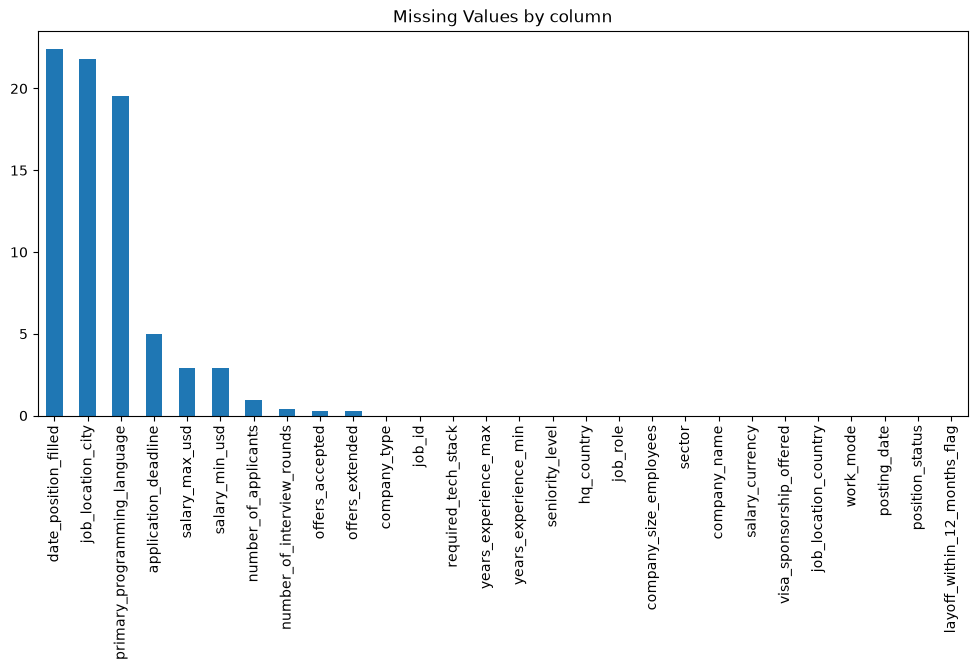

In [11]:
missing_percentage = df.isnull().mean()*100
sorted_missing = missing_percentage.sort_values(ascending=False)
sorted_missing.plot(kind="bar", figsize=(12,5))
plt.title("Missing Values by column")
plt.show()

In [12]:
df["job_id"].duplicated().sum()

np.int64(2000)

In [13]:
df = df.drop_duplicates().reset_index(drop=True)

df = df.drop_duplicates(subset=["job_id"], keep="last").reset_index(drop=True)

In [14]:
print(df.shape)
print(df.duplicated().sum())

(113000, 28)
0


### Observation

Complete duplicate records and duplicate job IDs were removed.
The cleaned dataset contains 113,000 unique job postings.

In [15]:
df["work_mode"].value_counts()

work_mode
Hybrid            48063
Remote            31752
Onsite            26302
HYBRID             1475
hybrid             1325
remote              588
Work From Home      555
WFH                 552
REMOTE              548
ONSITE              471
In-office           460
onsite              459
On-site             450
Name: count, dtype: int64

In [16]:
df["work_mode_clean"] = df["work_mode"].astype(str).str.strip().str.title()
work_mode_mapping = {
    "Wfh": "Remote",
    "Work From Home": "Remote",
    "Remote": "Remote",
    "In-Office": "Onsite",
    "On-Site": "Onsite",
    "Onsite": "Onsite",
    "Hybrid": "Hybrid"
}
df["work_mode_clean"] = df["work_mode_clean"].replace(work_mode_mapping)

In [17]:
df["work_mode_clean"].value_counts()

work_mode_clean
Hybrid    50863
Remote    33995
Onsite    28142
Name: count, dtype: int64

In [18]:
bool_map = {"1": 1, 1: 1, "Y": 1, "Yes": 1, "True": 1, True: 1, "0": 0, 0: 0, "N": 0, "No": 0, "False": 0, False: 0}

df["visa_sponsorship_clean"] = df["visa_sponsorship_offered"].map(bool_map)
df["layoff_flag_clean"] = df["layoff_within_12_months_flag"].map(bool_map)

In [19]:
df["visa_sponsorship_clean"].value_counts()


visa_sponsorship_clean
0    77542
1    35458
Name: count, dtype: int64

In [20]:
df["layoff_flag_clean"].value_counts()

layoff_flag_clean
0    98190
1    14810
Name: count, dtype: int64

In [21]:
df["company_type"].value_counts()

company_type
MNC           55081
Mid-size      19953
Unicorn       15811
FAANG-tier    15679
Startup        6476
Name: count, dtype: int64

In [22]:
df["position_status"].value_counts()

position_status
Filled       89483
Open          9985
Cancelled     7908
Withdrawn     5624
Name: count, dtype: int64

In [23]:
df["posting_date"] = pd.to_datetime(df["posting_date"])
df["date_position_filled"] = pd.to_datetime(df["date_position_filled"])

In [24]:
df["application_deadline"] = pd.to_datetime(df["application_deadline"],errors="coerce")

### Observation
- Date columns were converted to datetime format.
- invaid/non-date values become missing during conversion.

In [25]:
(df["years_experience_max"] < df["years_experience_min"]).sum()

np.int64(310)

### Observation
- some records have maximum experience below minimum experience.

In [26]:
(df["salary_max_usd"] < df["salary_min_usd"]).sum()

np.int64(16655)

### Observation

16,655 records contain salary ranges where the maximum salary is lower than the minimum salary. These records require correction before salary-based analysis.

In [27]:
(df["offers_extended"] < df["offers_accepted"]).sum()

np.int64(587)

### Observation
- some records have accepted offers greater than extended offers.

In [28]:
(df["posting_date"] > df["date_position_filled"]).sum()

np.int64(439)

### Observation
- some position have filled date earlier than the posting date.

In [29]:
df.loc[df["offers_accepted"] > df["offers_extended"], "offers_accepted"] = np.nan

df.loc[df["date_position_filled"] < df["posting_date"], "date_position_filled"] = pd.NaT

df.loc[df["number_of_applicants"] < 0, "number_of_applicants"] = np.nan

In [30]:
print((df["offers_accepted"] > df["offers_extended"]).sum())

print((df["posting_date"] > df["date_position_filled"]).sum())

print((df["number_of_applicants"] < 0).sum())

0
0
0


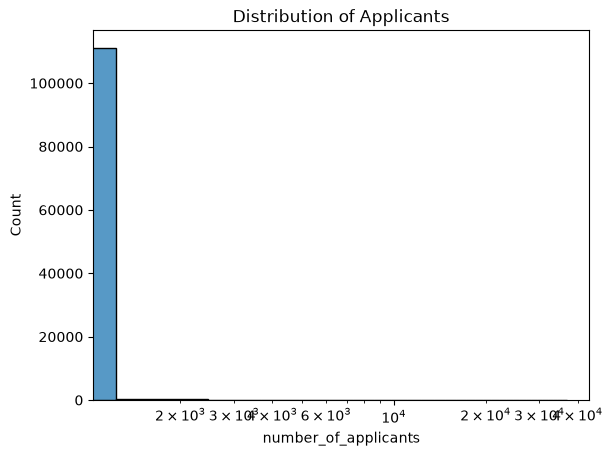

In [31]:
df_positive = df[df["number_of_applicants"] >= 0]
sns.histplot(df_positive["number_of_applicants"], bins=30)
plt.xscale("log")
plt.title("Distribution of Applicants")
plt.show()

In [32]:
df["number_of_applicants"].skew()

np.float64(32.53327356686255)

### Observation

Applicant counts are highly right-skewed, indicating that most
job postings receive relatively moderate application volumes,
while a small number of postings receive exceptionally large
numbers of applications.

In [33]:
df["number_of_applicants"].quantile([0.50, 0.75, 0.90, 0.95, 0.99])

0.50    119.0
0.75    214.0
0.90    349.0
0.95    471.0
0.99    863.0
Name: number_of_applicants, dtype: float64

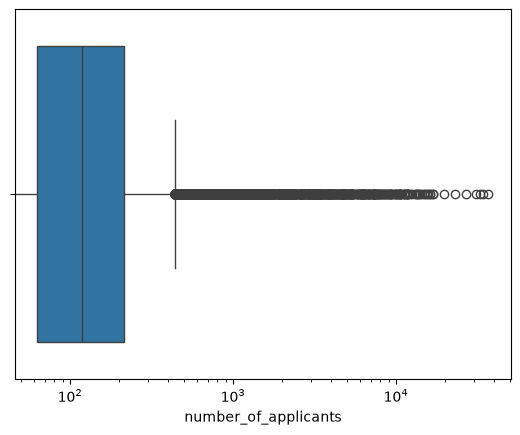

In [34]:
sns.boxplot(data=df, x= "number_of_applicants")
plt.xscale("log")

In [35]:
df["number_of_applicants"].describe()

count    111662.000000
mean        182.258351
std         439.430212
min           0.000000
25%          63.000000
50%         119.000000
75%         214.000000
max       36816.000000
Name: number_of_applicants, dtype: float64

### Observation

The median job posting receives about 119 applications,
while the maximum reaches 36,816. The large difference
between the median and maximum indicates substantial
variation and extreme high-application postings.

In [36]:
print((df["number_of_applicants"] > 1000).sum())

822


### Observation

838 job postings received more than 1,000 applications,
showing that a small subset of positions attracts exceptionally
high applicant interest.

### Observation

Applicant counts are strongly right-skewed. Most postings
receive a moderate number of applications, while a small
number attract exceptionally high applicant volumes.

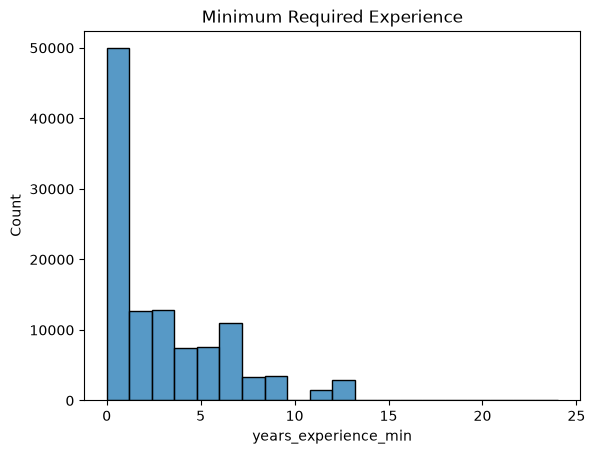

In [37]:
sns.histplot(df["years_experience_min"], bins=20 )
plt.title("Minimum Required Experience")
plt.show()

### Observation

Most job postings require relatively low to moderate
levels of prior experience. The median minimum requirement
is approximately 2 years, although some positions require
substantially more experience.

In [38]:
df["salary_min_usd"] = pd.to_numeric(df["salary_min_usd"], errors="coerce")
df["salary_max_usd"] = pd.to_numeric(df["salary_max_usd"], errors="coerce")
df.loc[df["salary_min_usd"] <= 0, "salary_min_usd"] = np.nan
df.loc[df["salary_max_usd"] <= 0, "salary_max_usd"] = np.nan

In [39]:
inv_exp = df["years_experience_max"] < df["years_experience_min"]
df.loc[inv_exp, ["years_experience_min", "years_experience_max"]] = df.loc[inv_exp, ["years_experience_max", "years_experience_min"]].values

inv_sal = df["salary_max_usd"] < df["salary_min_usd"]
df.loc[inv_sal, ["salary_min_usd", "salary_max_usd"]] = df.loc[inv_sal, ["salary_max_usd", "salary_min_usd"]].values

### Data Correction

When the reported maximum value was lower than the minimum,
the two values were assumed to have been entered in reverse
order and were swapped.

In [40]:
df["avg_salary"] = (df["salary_max_usd"] + df["salary_min_usd"])/2

### Note

Average salary is calculated as the midpoint of the reported
minimum and maximum salary range.

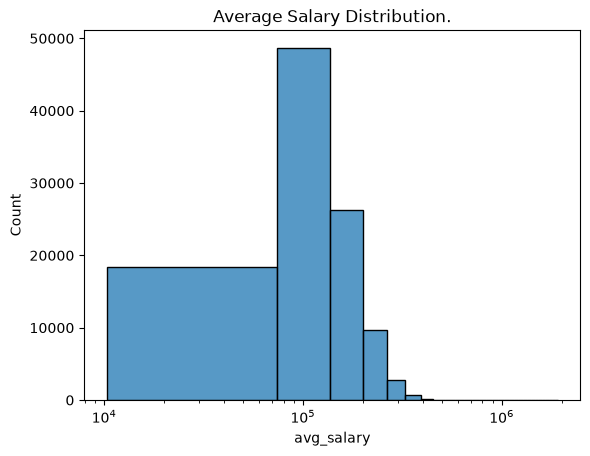

In [41]:
sns.histplot(df["avg_salary"], bins=30)
plt.xscale("log")
plt.title("Average Salary Distribution.")
plt.show()

### Observation

Salary distribution is strongly right-skewed. The median
average salary is approximately 117K, while a small number
of very high salary observations increase the mean to about
129K.

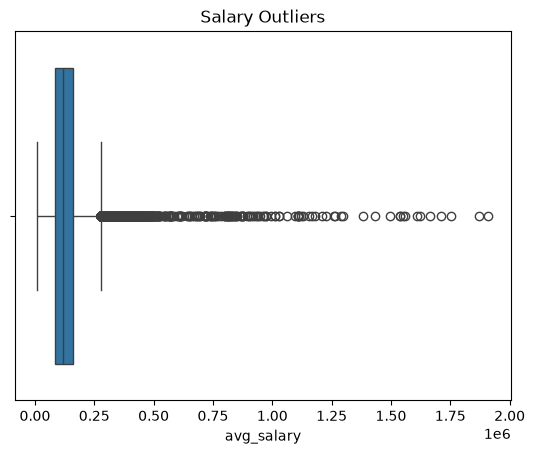

In [42]:
sns.boxplot(x=df["avg_salary"])
plt.title("Salary Outliers")
plt.show()

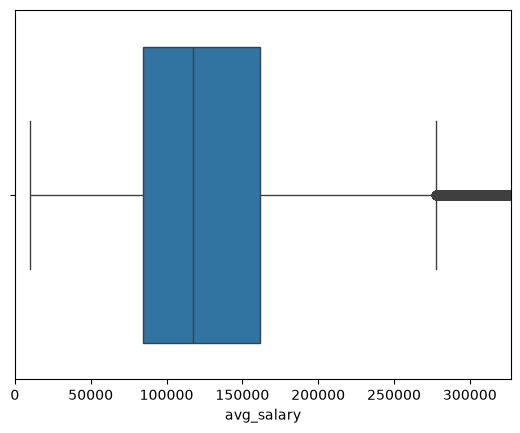

In [43]:
upper = df["avg_salary"].quantile(.99)

sns.boxplot(x=df["avg_salary"])

plt.xlim(0, upper)
plt.show()

### Observation
- Several potential salary outliers are visible.

In [44]:
df["sector_clean"] = (df["sector"].str.strip().str.title())

In [45]:
sector_map = {
    "Ai/Ml": "AI/ML",
    "E-Commerce": "E-commerce",
    "Healthtech": "HealthTech",
    "Edtech": "EdTech",
    "Saas": "SaaS",
    "Fintech": "Fintech"}

In [46]:
df["sector_clean"] = (df["sector_clean"].replace(sector_map))

In [47]:
df["sector_clean"].value_counts()

sector_clean
E-commerce       16554
HealthTech       15168
Fintech          13042
EdTech           11455
Social/Adtech     8962
AI/ML             8825
SaaS              8552
Crypto/Web3       7982
Cloud/Infra       6513
Cybersecurity     5677
Logistics         5256
Gaming            5014
Name: count, dtype: int64

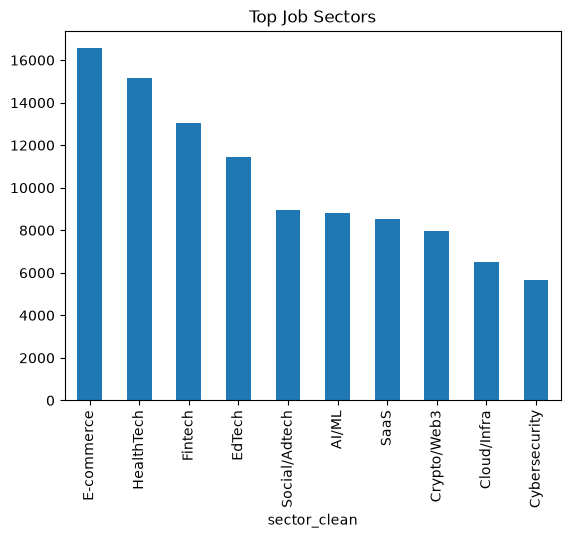

In [48]:
df["sector_clean"].value_counts().head(10).plot(kind="bar")

plt.title("Top Job Sectors")
plt.show()

### Observation

Job postings are distributed across multiple technology sectors,
with a smaller group of sectors accounting for a larger share
of total postings.

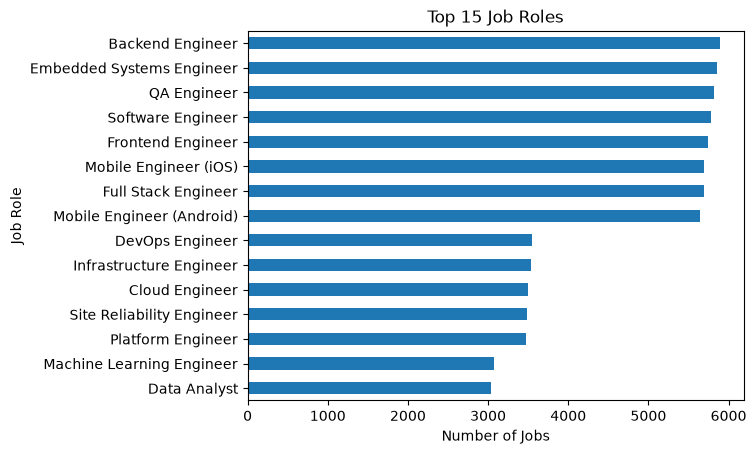

In [49]:
top_roles = df["job_role"].value_counts().head(15)

top_roles.sort_values().plot(kind="barh")

plt.title("Top 15 Job Roles")
plt.xlabel("Number of Jobs")
plt.ylabel("Job Role")
plt.show()

### Observation
- The dataset contains diverse technology roles.
- Some roles occur more frequently than others.

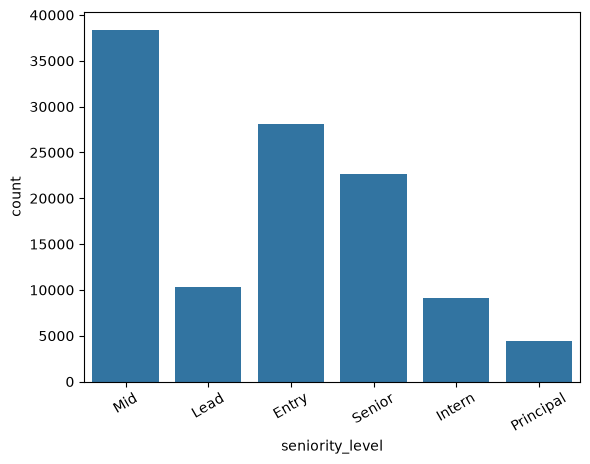

In [50]:
sns.countplot(data=df, x="seniority_level")

plt.xticks(rotation=30)
plt.show()

### Observation
- Multiple seniority levels are represented.
- Job-posting volume differs across career levels.

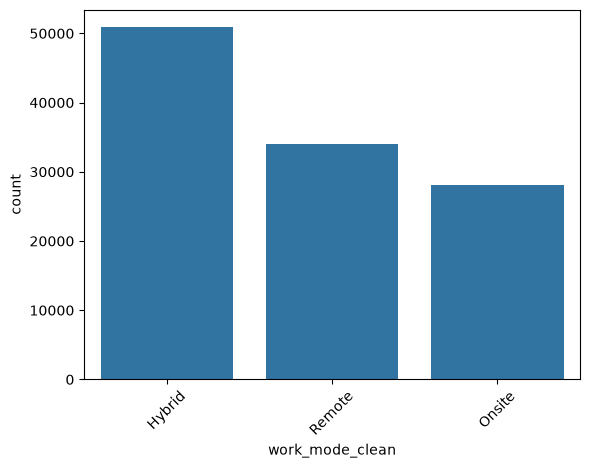

In [51]:
sns.countplot(data=df, x="work_mode_clean")

plt.xticks(rotation=45)
plt.show()

### Observation

Hybrid positions are the most common work arrangement,
followed by Remote and Onsite positions.

In [52]:
df["primary_programming_language"] = (df["primary_programming_language"].replace(["Unknown", "TBD"], np.nan))

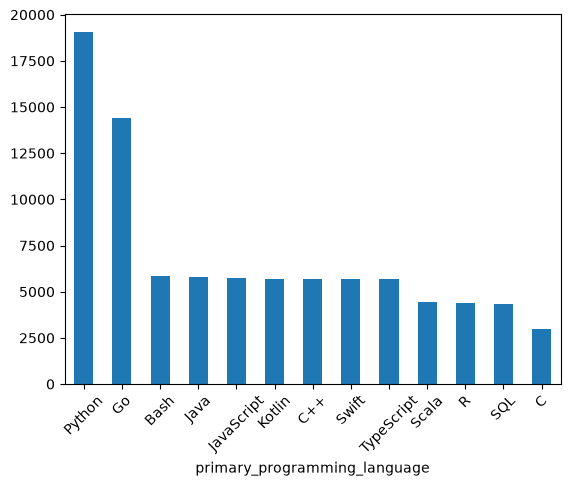

In [53]:
df["primary_programming_language"].value_counts().plot(kind="bar")

plt.xticks(rotation=45)
plt.show()

### Observation

Python is the most frequently reported primary programming
language, followed by Go and other languages including Bash,
Java, JavaScript, and C++.

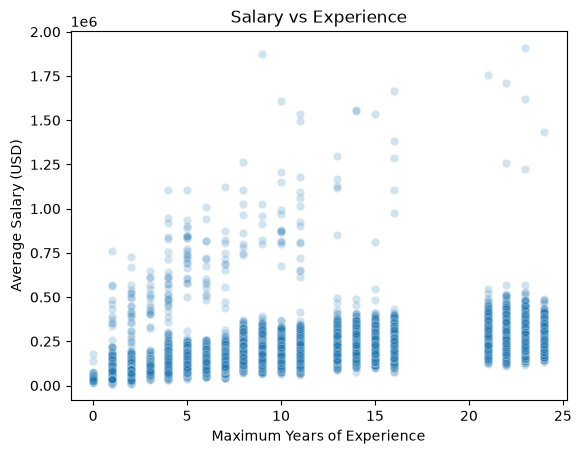

In [54]:
sns.scatterplot(data=df, x="years_experience_max", y="avg_salary", alpha=0.2)

plt.title("Salary vs Experience")
plt.xlabel("Maximum Years of Experience")
plt.ylabel("Average Salary (USD)")
plt.show()

### Observation
- Salary varies with required experience.
- Higher-experience roles generally occupy higher salary ranges.
- The relationship is not perfectly linear.

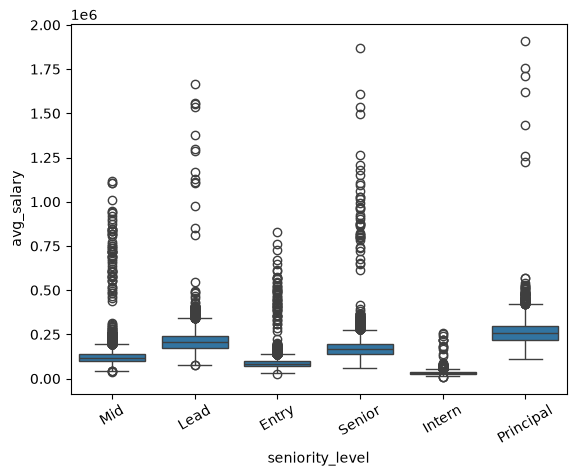

In [55]:
sns.boxplot(data=df, x="seniority_level", y="avg_salary")

plt.xticks(rotation=30)
plt.show()

### Observation
- Salary distributions differ across seniority levels.
- Senior-level positions generally have higher salary ranges.

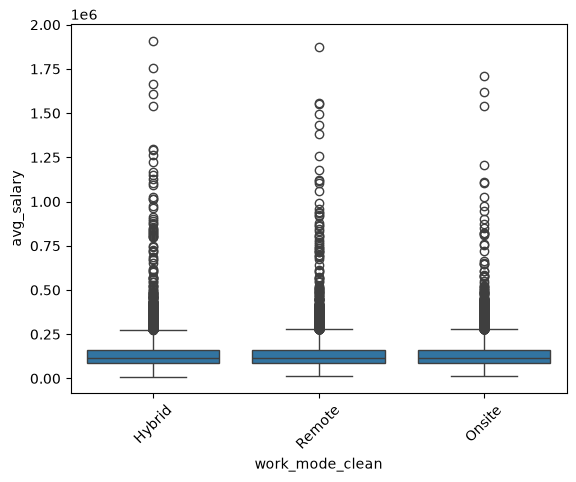

In [56]:
sns.boxplot(data=df, x="work_mode_clean", y="avg_salary")

plt.xticks(rotation=45)
plt.show()

### Observation
- Salary distributions vary across work modes.
- Work mode alone does not explain salary differences.

In [57]:
sector_salary = (df.groupby("sector_clean")["avg_salary"].median().sort_values())

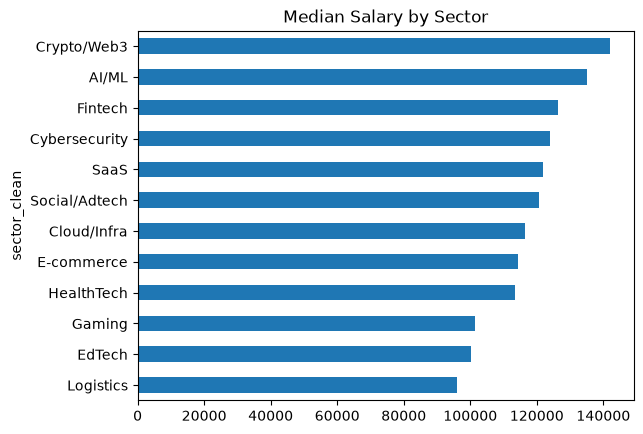

In [58]:
sector_salary.plot(kind="barh")
plt.title("Median Salary by Sector")

plt.show()

### Observation
- Salary distributions vary across sectors.
- Some sectors show higher typical salary levels.

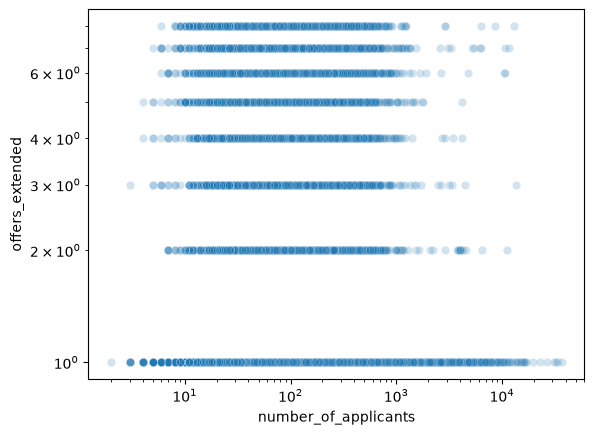

In [59]:
sns.scatterplot(data=df, x="number_of_applicants", y="offers_extended", alpha=.2)

plt.xscale("log")
plt.yscale("log")

plt.show()

### Observation
- Applicant volume varies considerably across postings.
- Offer counts generally remain much smaller than applicant counts.
- Inconsistent records were identified during logical checks.

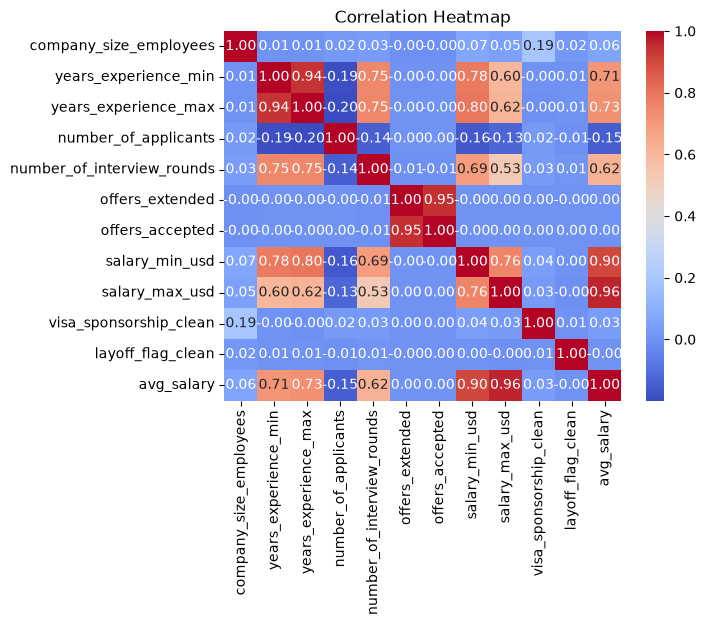

In [60]:
num = df.select_dtypes("number")

sns.heatmap(num.corr(), annot=True, fmt=".2f", cmap="coolwarm")


plt.title("Correlation Heatmap")
plt.show()

### Observation
- Numerical variables show different levels of correlation.
- Experience and salary-related variables show meaningful associations.
- Correlation does not imply causation.

In [61]:
df["year"] = df["posting_date"].dt.year

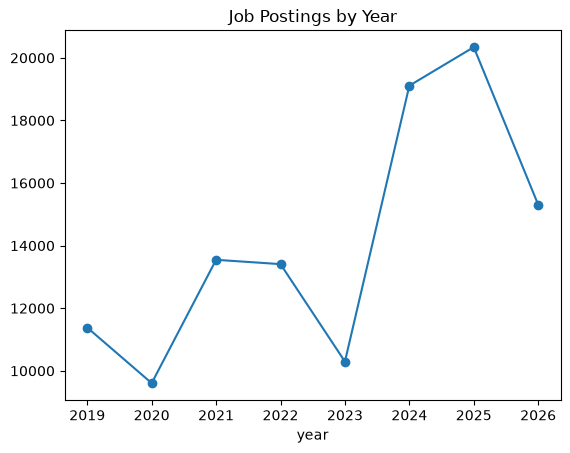

In [62]:
df["year"].value_counts().sort_index().plot(kind="line", marker="o")

plt.title("Job Postings by Year")
plt.show()

### Observation
- Job-posting volume changes across years.
- Some years show noticeable increases or decreases in activity.

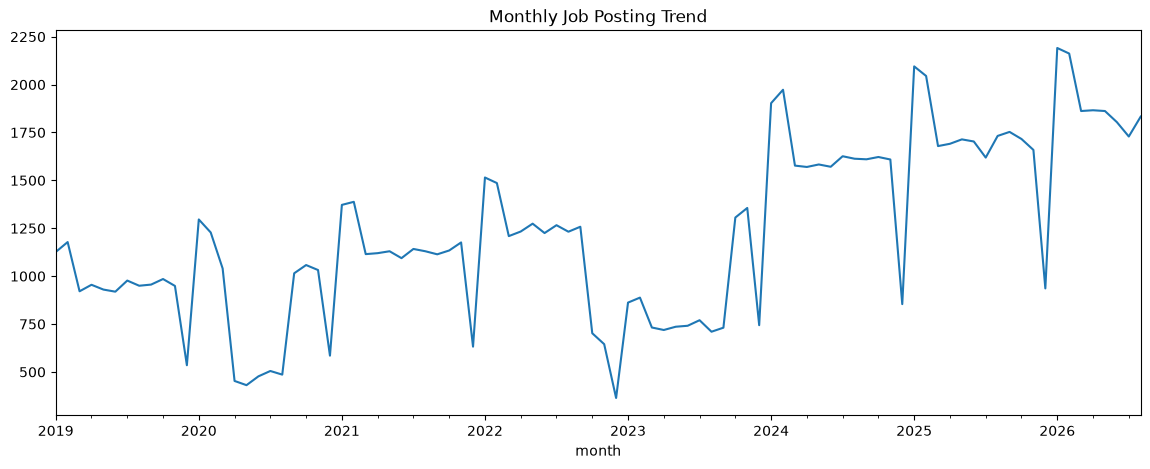

In [63]:
df["month"] = df["posting_date"].dt.to_period("M")

df.groupby("month").size().plot(figsize=(14,5))

plt.title("Monthly Job Posting Trend")
plt.show()

### Observation
- Job-posting activity fluctuates from month to month.
- The time series highlights periods of higher and lower hiring activity.

In [64]:
df["time_to_fill_days"] = (df["date_position_filled"] - df["posting_date"]).dt.days

In [65]:
df["offer_accept_ratio"] = np.where(df["offers_extended"] > 0, df["offers_accepted"] / df["offers_extended"], np.nan)

In [66]:
df["tech_count"] = df["required_tech_stack"].str.split(",").str.len()

### Observation
- Average salary summarizes the salary range.
- Time to fill measures hiring duration.
- Offer acceptance ratio measures hiring conversion.

In [67]:
tech = (df["required_tech_stack"].str.split(",").explode().str.strip())

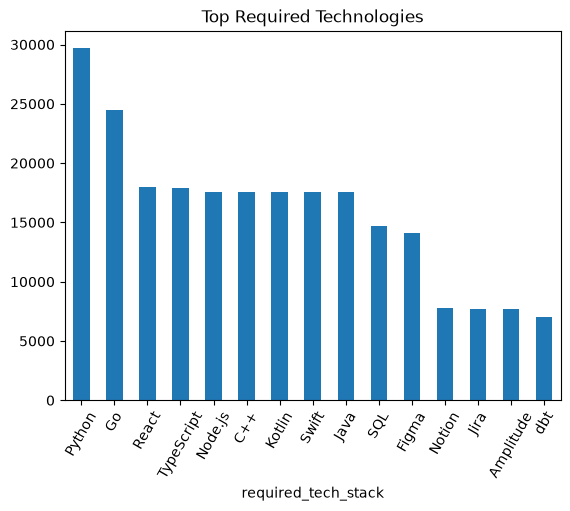

In [68]:
tech.value_counts().head(15).plot(
    kind="bar"
)

plt.title("Top Required Technologies")
plt.xticks(rotation=60)
plt.show()

### Observation
- Job postings require a wide range of technologies.
- A smaller group of technologies appears frequently across postings.

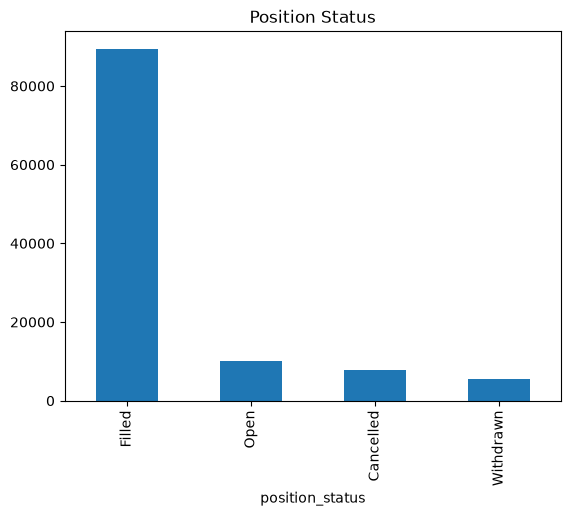

In [69]:
df["position_status"].value_counts().plot(
    kind="bar"
)

plt.title("Position Status")
plt.show()

### Observation

Most job postings in the dataset are marked as Filled,
while smaller proportions remain Open, Cancelled, or Withdrawn.

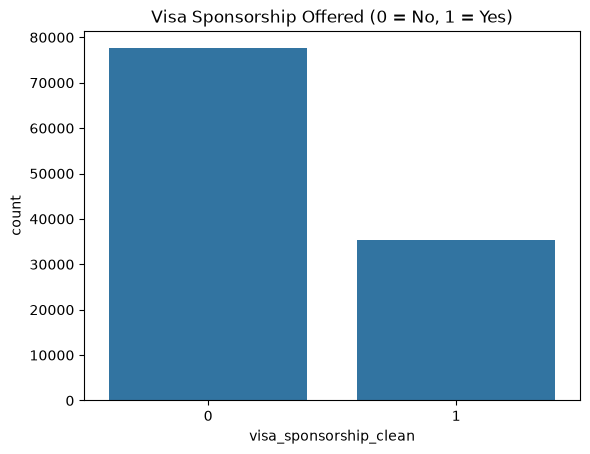

In [70]:
sns.countplot(data=df, x="visa_sponsorship_clean")
plt.title("Visa Sponsorship Offered (0 = No, 1 = Yes)")
plt.show()

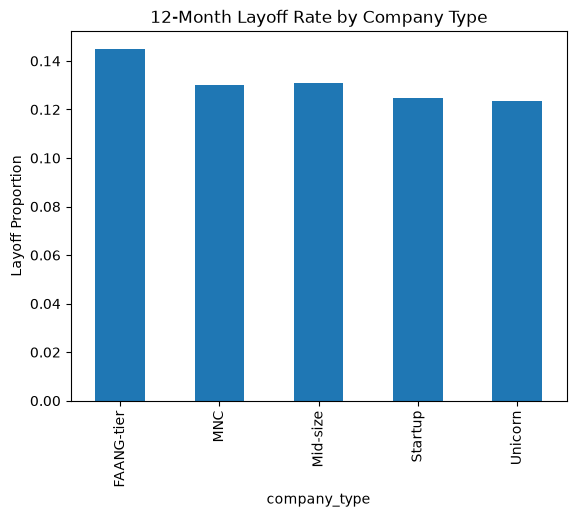

In [71]:
df.groupby("company_type")["layoff_flag_clean"].mean().plot(kind="bar")
plt.title("12-Month Layoff Rate by Company Type")
plt.ylabel("Layoff Proportion")
plt.show()

### Observation

FAANG-tier companies have the highest observed 12-month
layoff flag rate at approximately 14.5%, while Unicorns
have the lowest at approximately 12.4%.

These results describe associations in this dataset and
should not be interpreted as evidence that company type
causes layoffs.

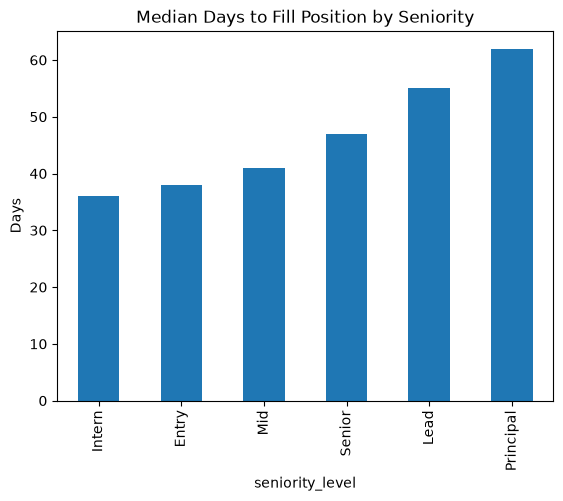

In [72]:
df.groupby("seniority_level")["time_to_fill_days"].median().sort_values().plot(kind="bar")
plt.title("Median Days to Fill Position by Seniority")
plt.ylabel("Days")
plt.show()

In [73]:
company_salary = (df.groupby("company_type")["avg_salary"].median().sort_values())

company_salary

company_type
Startup        94700.0
Mid-size      102200.0
MNC           116850.0
Unicorn       123250.0
FAANG-tier    148700.0
Name: avg_salary, dtype: float64

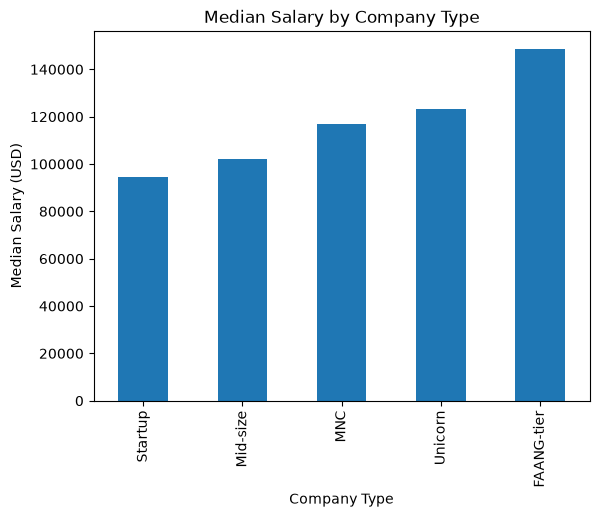

In [74]:
company_salary.plot(kind="bar")

plt.title("Median Salary by Company Type")
plt.xlabel("Company Type")
plt.ylabel("Median Salary (USD)")
plt.show()

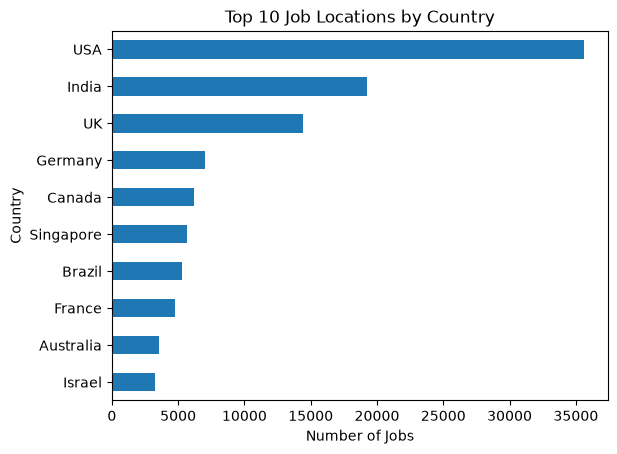

In [75]:
country_counts = (df["job_location_country"].value_counts().head(10))

country_counts.sort_values().plot(kind="barh")

plt.title("Top 10 Job Locations by Country")
plt.xlabel("Number of Jobs")
plt.ylabel("Country")
plt.show()

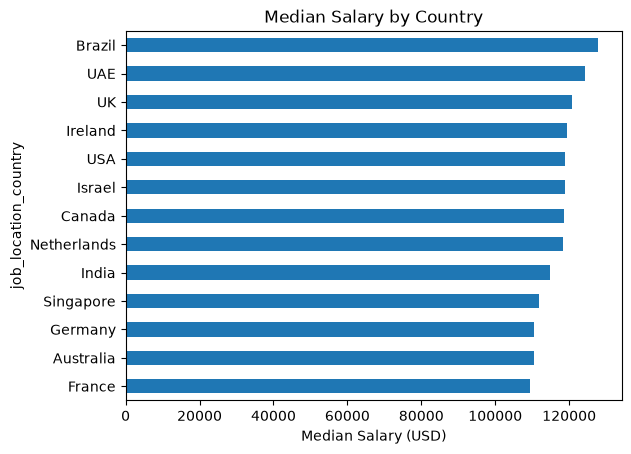

In [76]:
country_salary = (df.groupby("job_location_country")["avg_salary"].median().sort_values())

country_salary.plot(kind="barh")

plt.title("Median Salary by Country")
plt.xlabel("Median Salary (USD)")
plt.show()

In [77]:
funnel = df[["number_of_applicants",
        "number_of_interview_rounds",
        "offers_extended",
        "offers_accepted"]].mean()

funnel

number_of_applicants          182.258351
number_of_interview_rounds      3.307498
offers_extended                 1.348738
offers_accepted                 1.186996
dtype: float64

In [78]:
df["tech_count"].describe()

count    113000.000000
mean          3.464602
std           1.106320
min           2.000000
25%           2.000000
50%           3.000000
75%           4.000000
max           5.000000
Name: tech_count, dtype: float64

### Observation
- Most job postings require around three technologies, while some positions require a broader technology stack.

# Data Quality Summary

- Missing values were identified and quantified.
- Complete duplicate rows were removed.
- Duplicate job IDs were removed.
- Inconsistent work-mode labels were standardized.
- Boolean fields were standardized.
- Date columns were converted to datetime format.
- Invalid experience ranges were corrected.
- Reversed salary ranges were corrected.
- Invalid offer relationships were identified and corrected.
- Invalid date relationships were corrected.
- Negative applicant counts were treated as missing.
- Non-numeric salary values were converted to missing values.
- Extreme values were investigated rather than automatically removed.